**Medical insurance dataset and pricing model**

**Introduction**

Insurance providers gather customer data to assess which factors influence claim costs and to make informed pricing decisions. By understanding what variables contribute to insurance charges, an insurance provider can price policies fairly and manage financial risk, which is essential to good business practice and financial health; insurers may also introduce health initiatives that help mitigate future risk.\
This project investigates which variables positively and negatively affect insurance charges, the response variable, using a dataset which provides many important explanatory variables. The investigation will use exploratory data analysis and statistical modelling to identify important variables and use them to create a predictive model appropriate for insurance pricing applications.

**Dataset overview**

The dataset gives the response variable, insurance charges and many potential explanatory variables which include: age, BMI, smoking, region a customer lives and the number of children a customer has. 

**Load the dataset and check**

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
#load the dataset and check 
Insurance_Dataset <- read.csv("insurance.csv")
head(Insurance_Dataset)
tail(Insurance_Dataset)

,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1333,52,female,44.70,3,no,southwest,11411.685
1334,50,male,30.97,3,no,northwest,10600.548
1335,18,female,31.92,0,no,northeast,2205.981
1336,18,female,36.85,0,no,southeast,1629.833
1337,21,female,25.80,0,no,southwest,2007.945
1338,61,female,29.07,0,yes,northwest,29141.360


The dataset contains the response variable of insurance charges, and the explanatory variables of age, sex, bmi, number of children, whether the customer is a smoker and the region a customer lives in.

**Examining and cleaning the dataset**

In [3]:
#Number of children should be a factor so I can test this variable as an explanatory variable in EDA plots.
Insurance_Dataset$children <- as.factor(Insurance_Dataset$children)

In [4]:
#Rename variables to improve readability.
Insurance_Dataset <- Insurance_Dataset %>%
  rename(
    Age = age,
    Sex = sex,
    BMI = bmi,
    Number_of_Children = children,
    Smoker = smoker,
    Region = region,
    Insurance_Charges = charges
  )

In [5]:
ID <- Insurance_Dataset
head(ID)

,Age,Sex,BMI,Number_of_Children,Smoker,Region,Insurance_Charges
,<int>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


Let's engineer some new features from the dataset. A good idea would be separate age into groups and BMI into categorys, using the NHS defined categories of BMI.

In [6]:
#new column for age group
ID <- ID %>%
    mutate(
       Age_Group =
        case_when(
            Age < 30 ~ "Young_Adult",
            Age < 45 ~ "Adult",
            Age < 60 ~ "Middle_Aged",
            TRUE ~ "Old_Aged"
            )
        )

head(ID)

,Age,Sex,BMI,Number_of_Children,Smoker,Region,Insurance_Charges,Age_Group
,<int>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<chr>
1,19,female,27.900,0,yes,southwest,16884.924,Young_Adult
2,18,male,33.770,1,no,southeast,1725.552,Young_Adult
3,28,male,33.000,3,no,southeast,4449.462,Young_Adult
4,33,male,22.705,0,no,northwest,21984.471,Adult
5,32,male,28.880,0,no,northwest,3866.855,Adult
6,31,female,25.740,0,no,southeast,3756.622,Adult


In [7]:
#new column for BMI group
ID <- ID %>%
    mutate(
        BMI_Group =
         case_when(
            BMI < 18.5 ~ "Underweight",
            BMI < 25 ~ "Healthy_Weight",
            BMI < 30 ~ "Overweight",
            BMI < 40 ~ "Obese",
            TRUE ~ "Severely_Obese"
            )
        )

head(ID)

,Age,Sex,BMI,Number_of_Children,Smoker,Region,Insurance_Charges,Age_Group,BMI_Group
,<int>,<chr>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,19,female,27.900,0,yes,southwest,16884.924,Young_Adult,Overweight
2,18,male,33.770,1,no,southeast,1725.552,Young_Adult,Obese
3,28,male,33.000,3,no,southeast,4449.462,Young_Adult,Obese
4,33,male,22.705,0,no,northwest,21984.471,Adult,Healthy_Weight
5,32,male,28.880,0,no,northwest,3866.855,Adult,Overweight
6,31,female,25.740,0,no,southeast,3756.622,Adult,Overweight


In [8]:
#check how many data points there are for each new category.
table(ID$Age_Group)
table(ID$BMI_Group)


      Adult Middle_Aged    Old_Aged Young_Adult 
        392         415         114         417 


Healthy_Weight          Obese     Overweight Severely_Obese    Underweight 
           225            616            386             91             20 

I have a small group for the underweight category, which should be treated with caution as smaller groups are sensitive to outliers. 

First, let's look at the distribution of the target variable (Insurance_Charges).

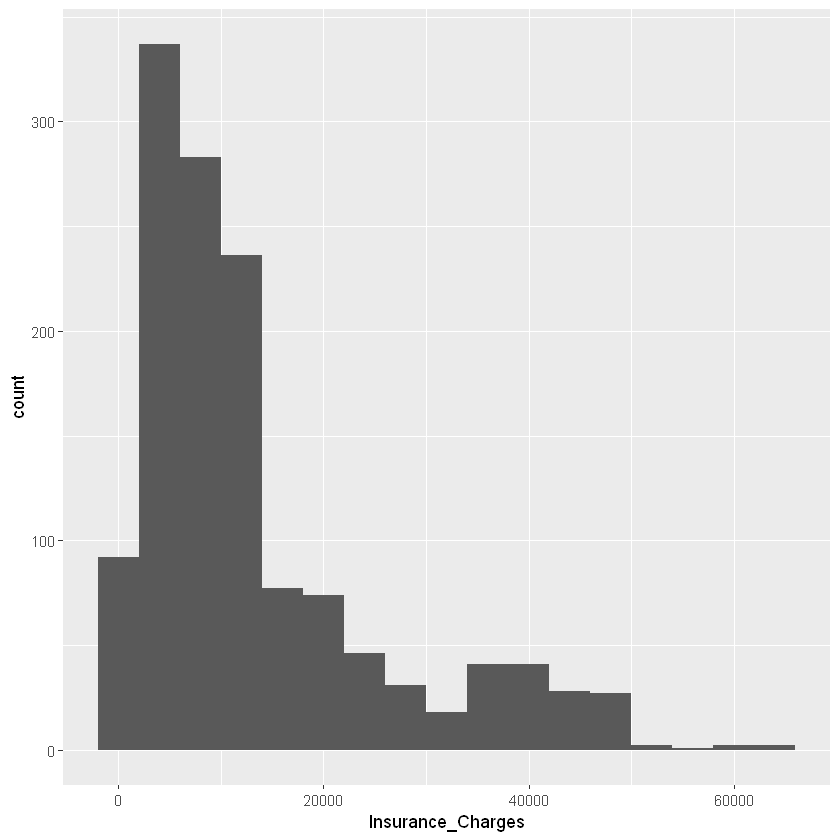

In [9]:
ggplot(data = ID, aes(x = Insurance_Charges)) +
    geom_histogram(binwidth = 4000)

The distribution of insurance charges is right skew, with a peak of around 5000. Most customers have modest insurance charges but some customers insurance charges are quite expensive. A long right tail indicates that extreme high costs may strongly influence the mean and regression models.

In [10]:
#calculating the percentage of insurance charges above 10,000
ID %>%
    summarise(
        Percentage_Above_10000 =
            mean(Insurance_Charges > 10000) * 100
        )

Percentage_Above_10000
<dbl>
46.78625


A substantial proportion of insurance charges are above 10000 (46.8%), almost half of the data. This indicates that certain customer characteristics may have a substantial influence on pricing.

At this point, I think it is wise to consider which type of GLM I may want to use. Given the shape of the insurance charge distribution, I would consider maybe using a linear model on log charges or a gamma GLM. 

My suspicion is that smoking category will be a strong influencer of insurance costs. As this is a categorical variable, I should use a boxplot and summarise the counts.

**Exploratory data analysis**

Let's first investigate the difference in insurance charges between customers who smoke and customers who don't smoke.

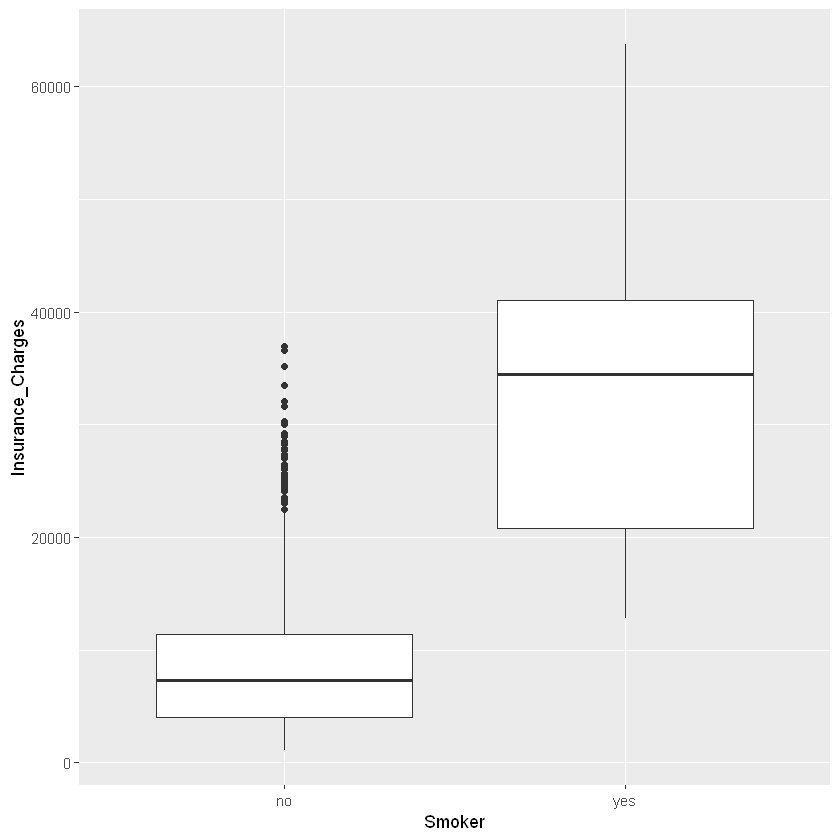

In [11]:
ggplot(data = ID, aes(x = Smoker, y = Insurance_Charges)) +
    geom_boxplot()

Immediately, there appears to be strong visual evidence that smoking status is associated with insurance charges. It is interesting that there are outliers for the non smoking category which  give expensive insurance charges, which needs further investigation. It may suggest another variable is interacting with the smoker variable. Almost 75% of the data for non smokers gives insurance costs of 10,000 or less, indicating that the majority of the most expensive insurance charges are for customers associated with the smoking category. 

In [12]:
#Summary statistics for smokers and non smokers
ID %>%
    group_by(Smoker) %>%
    summarise(
        Count = n(),
        Mean_Charges = mean(Insurance_Charges),
        Median_Charges = median(Insurance_Charges),
        Minimum = min(Insurance_Charges),
        Maximum = max(Insurance_Charges)
        )

Smoker,Count,Mean_Charges,Median_Charges,Minimum,Maximum
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
no,1064,8434.268,7345.405,1121.874,36910.61
yes,274,32050.232,34456.348,12829.455,63770.43


For smokers, the mean, median, minimum and maximum insurance charges are all more expensive than the non smokers summary statistics. Which provides further evidence that smoking may be an important explanatory variable. It's interesting that the minimum insurance charge for a smoker is approximately 3 times less than the maximum charge for a non smoker, which gives further evidence for one or more variables having an effect on insurance charges. I would speculate that BMI value and age would have an effect, so let's keep investigating.

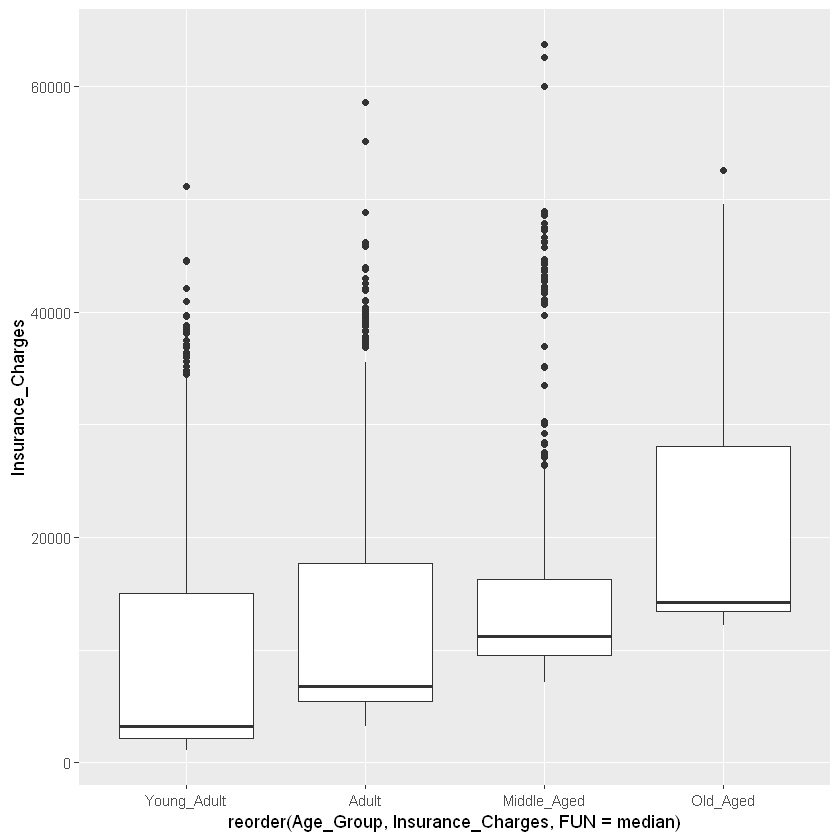

In [13]:
#Investigating insurance charges by age group, ordered from youngest to oldest
ggplot(data = ID, aes(x = reorder(Age_Group,
                                  Insurance_Charges,
                                  FUN = median),
                      y = Insurance_Charges)) +
    geom_boxplot()

By ordering the boxplots in terms of age, and by the median value, insurance charges seem to get more expensive with age. There is strong visual evidence that insurance charges tend to increase with age. This aligns with expectations but further investigation is needed. 

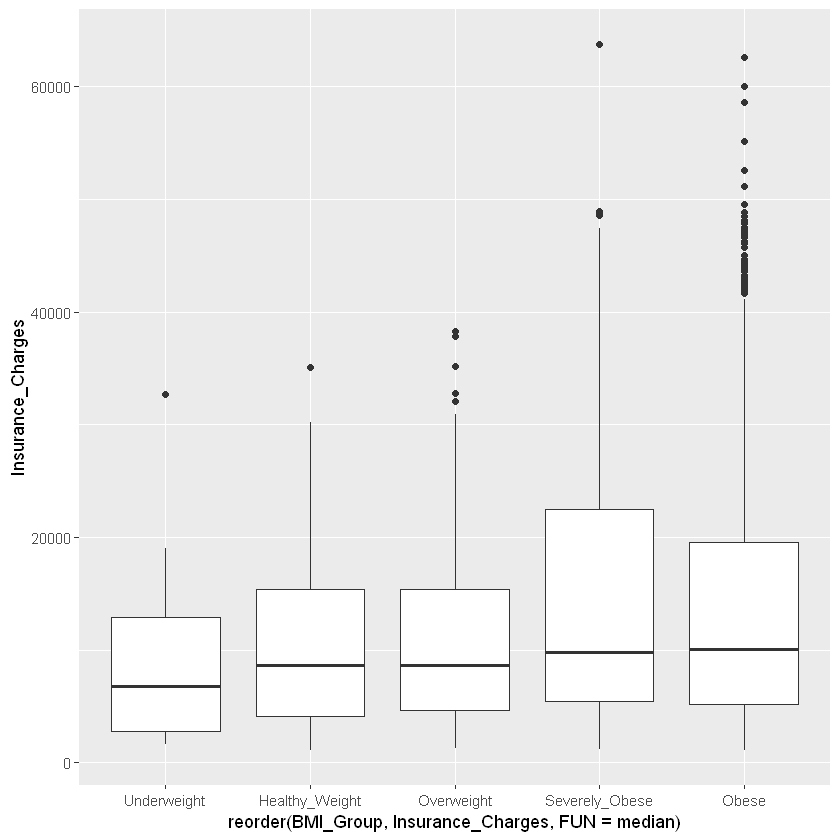

In [14]:
ggplot(data = ID, aes(x = reorder(BMI_Group,
                                  Insurance_Charges,
                                  FUN = median),
                      y = Insurance_Charges)) +
    geom_boxplot()

Interestingly, underweight, as arranged by median value produces generally cheaper insurance charges than healthy weight, which may be due to the fact that the group is small. Interestingly, the severely obese category does not produce the highest median insurance charge. This may be partly due to the smaller number of observations within this group, as well as the influence of other important variables such as age and smoking status. Let's try ordering them in terms of their mean.

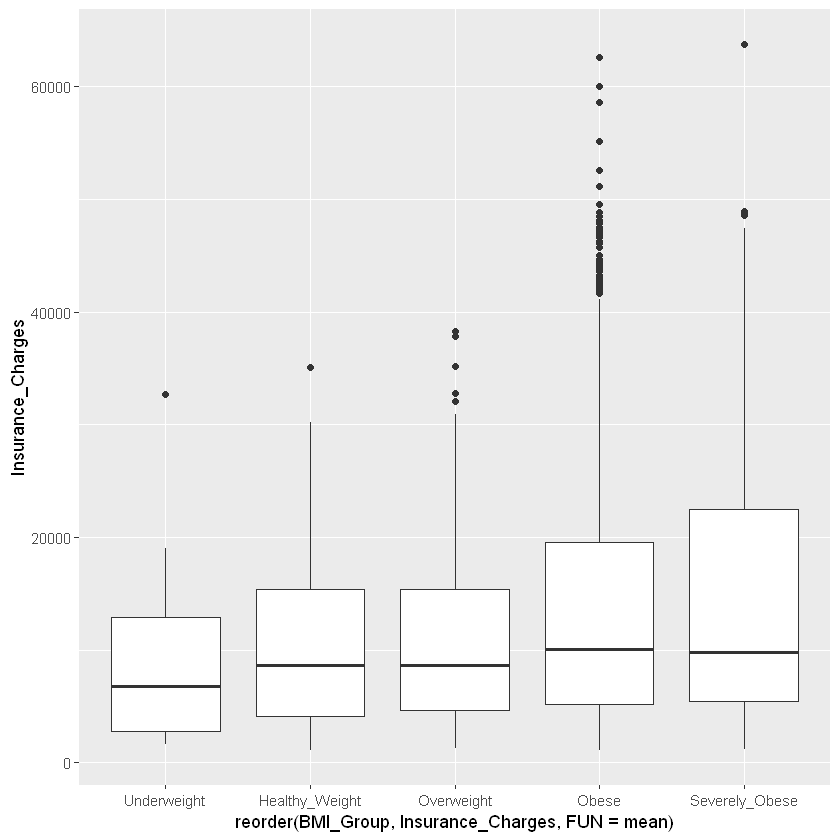

In [15]:
ggplot(data = ID, aes(x = reorder(BMI_Group,
                                  Insurance_Charges,
                                  FUN = mean),
                      y = Insurance_Charges)) +
    geom_boxplot()

When ordered by mean insurance charge, the categories appear more closely aligned with expectations. Because the mean incorporates all observations, including extreme values, groups containing a greater number of high-cost customers will tend to move higher in the ordering.\
There are outliers across all BMI groups which indicates to me that BMI alone doesn't completely explain insurance charges. Some customers within lower-risk BMI groups still incur expensive costs. It seems that other variables, such as smoking status, could be meaningfully contributing to insurance pricing.

Let's try insurance charges against the other variables.

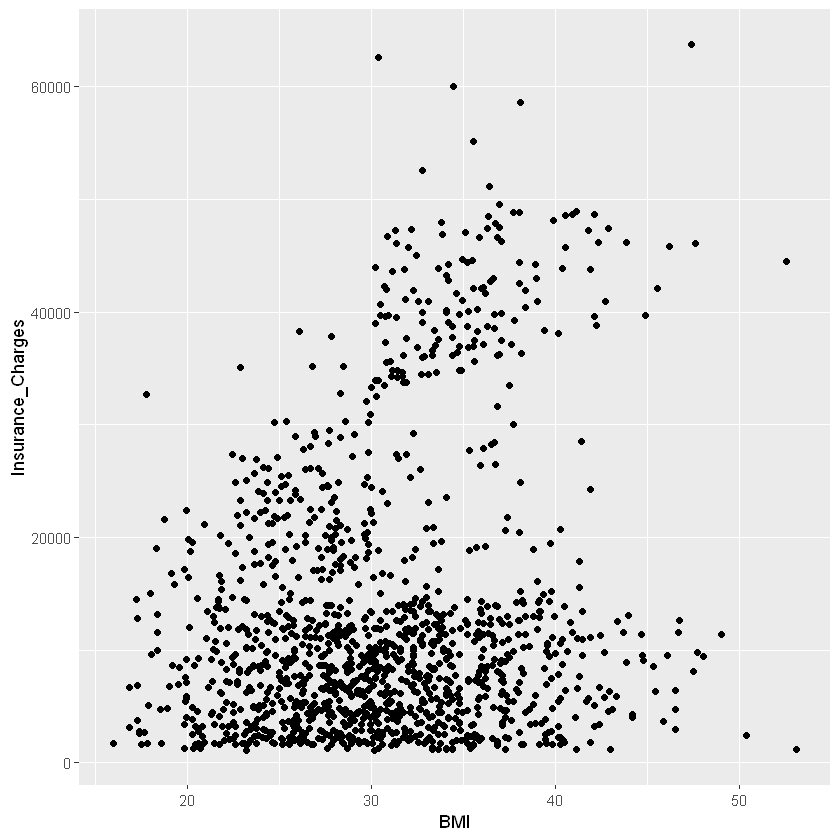

In [16]:
ggplot(data = ID, aes(x = BMI, y = Insurance_Charges)) +
    geom_point()

This plot produces an interesting outcome. There are potentially 3 clusters of data points, roughly at 0 - 15,000 Insurance charges and BMI 0 - 55, insurance charges 15,000 - 35,000 and BMI 10 - 45 and insurance charges 35,000 - 65,000 and BMI 30 - 55. This indicates that another variable may be interacting with BMI, my initial thought would be smoking status so I will investigate that next. 

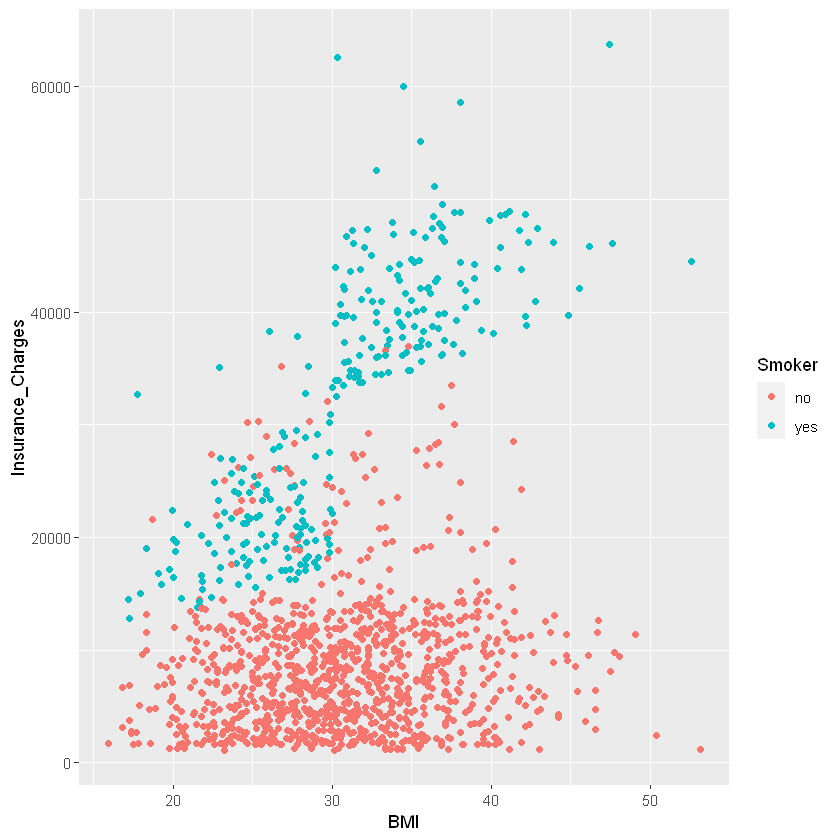

In [17]:
ggplot(data = ID, aes(x = BMI, y = Insurance_Charges, colour = Smoker)) +
    geom_point()

The graph shows strong visual evidence that smoking status has an effect on insurance charges, due to how well smoking separates the most expensive and cheapest insurance charges. I'm curious about the middle cluster though because it appears that smoking status and BMI are not the only variables interacting with each other. Let's investigate another variable which I think may be having an effect. 

Let's examine whether age may be causing the middle cluster of data points to appear.

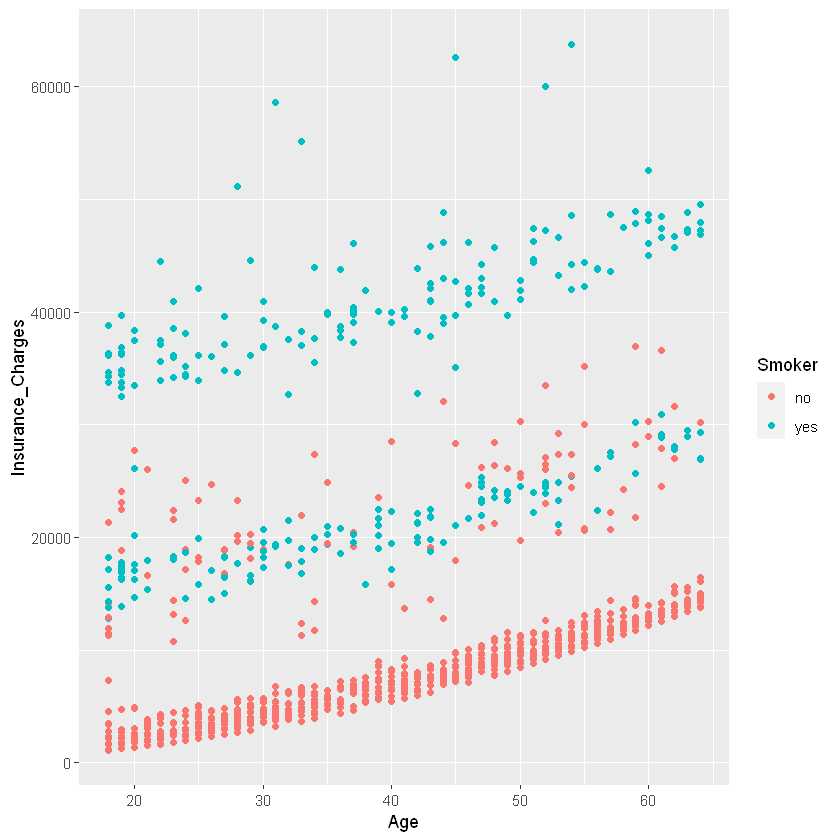

In [18]:
ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = Smoker)) +
    geom_point()

The plot is showing me the 3 clusters with the middle cluster perhaps being explained by another variable, as I can't separate the points at the moment. However the Age variable shows a positive linear effect on insurance charges. In other words, the older a customer is, the more expensive the insurance charges likely are.

Let's see if BMI and age are interacting with each other to influence insurance prices.

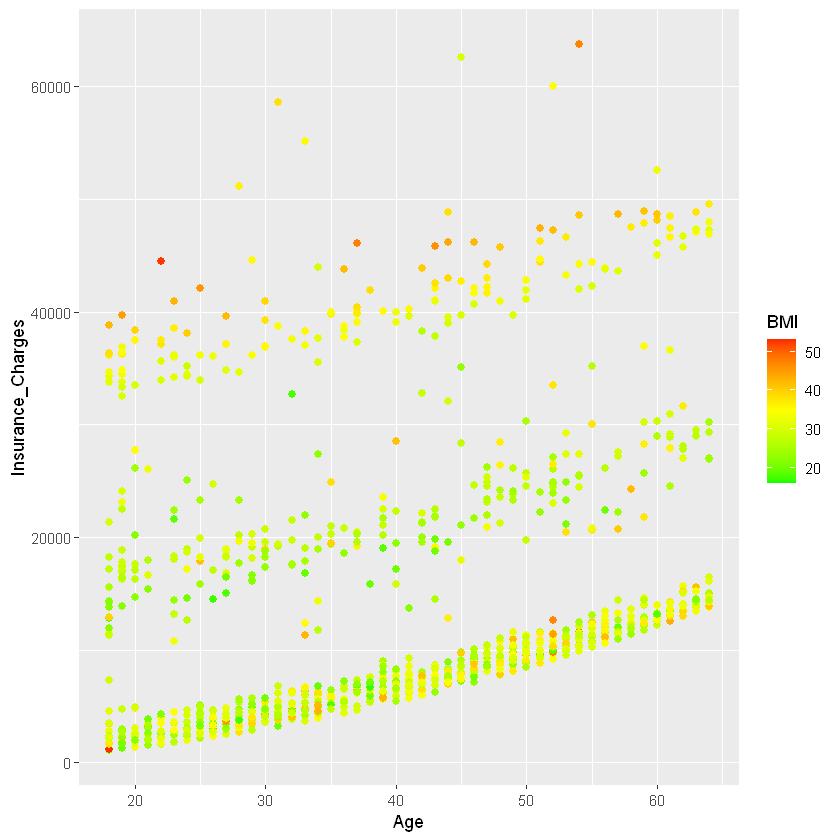

In [19]:
ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = BMI)) + 
    geom_point(size = 2) +
    scale_colour_gradient2(
        low = "green",
        mid = "yellow",
        high = "red",
        midpoint = 35
        )

So it seems there is still a middle cluster for this plot. Although it suggests some evidence that higher BMI typically means higher insurance charges. Overall I think this plot doesn't provide any stronger evidence for the variables than I already have.

Let's see if we can find a variable which may be causing the middle cluster to appear. I suspect that it will be a combination of things for this cluster where is no obvious divide. 

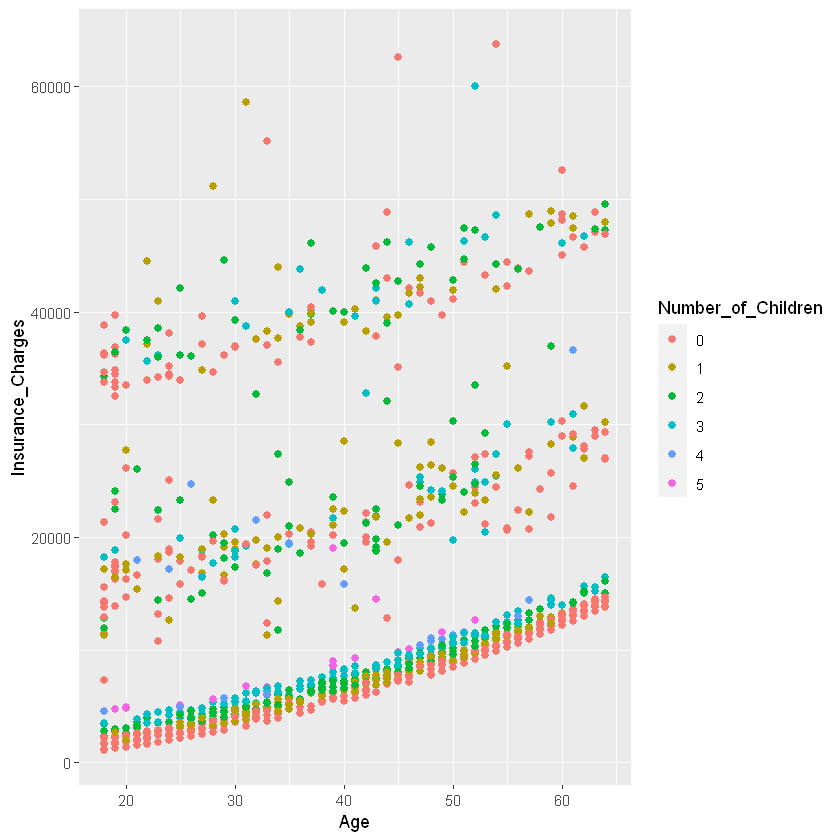

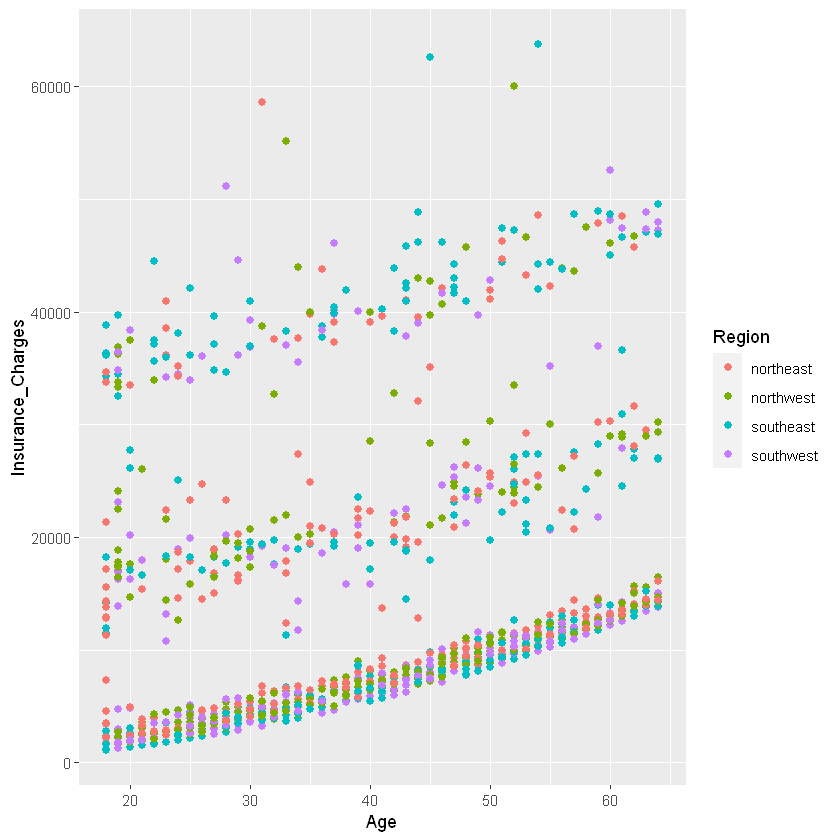

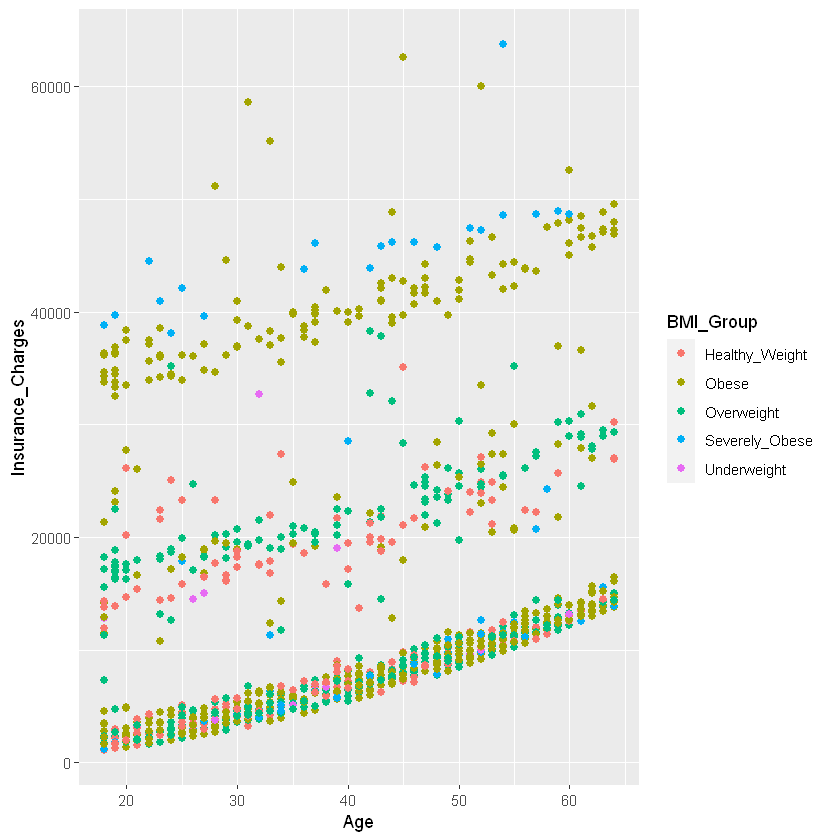

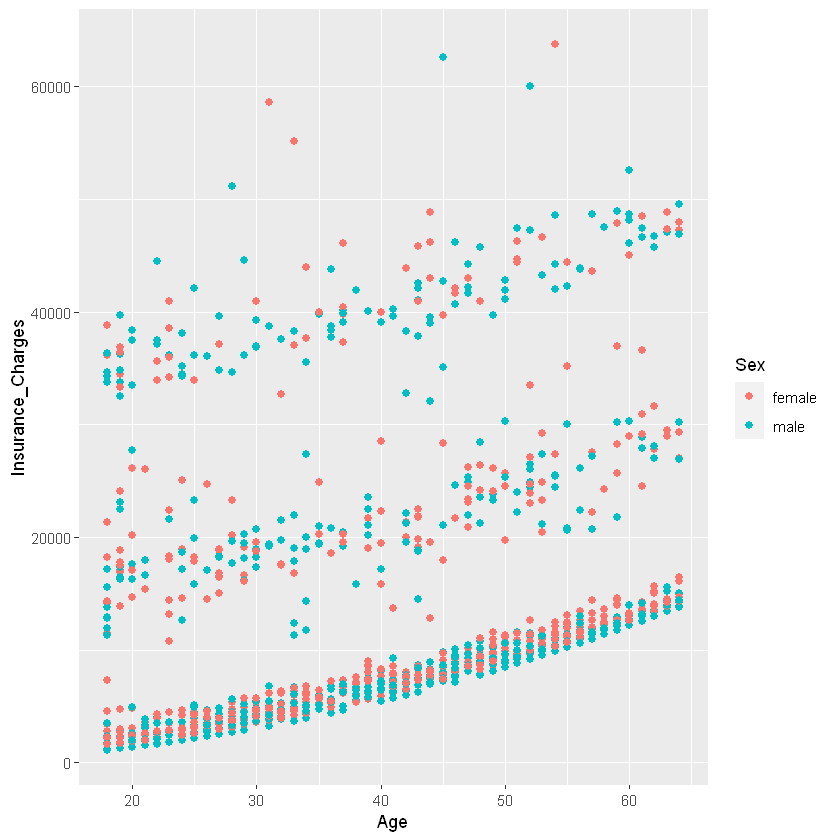

In [20]:
plot_1 <- ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = Number_of_Children)) +
    geom_point(size = 2)
plot_2 <- ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = Region)) +
    geom_point(size = 2)
plot_3 <- ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = BMI_Group)) +
    geom_point(size = 2)
plot_4 <- ggplot(data = ID, aes(x = Age, y = Insurance_Charges, colour = Sex)) +
    geom_point(size = 2)

plot_1
plot_2
plot_3
plot_4

Out of all the plots, it appears that the middle cluster may be influenced by a combination of smoking status, BMI, and age. While BMI group appears to play an important role, it is unlikely to explain the entire pattern by itself. This is because, having looked at the plots, there are only a few points which appear in the most expensive insurance charges cluster from the overweight category. It seems that if a customer is overweight but doesn't smoke, then they aren't seen as much of a risk as someone who is obese or severely obese. The overweight BMI group category likely puts customers in either the lower insurance charges or the middle insurance charges cluster. It seems the borderline between the middle and highest insurance charges is whether or not a customer either smokes, or is in the obese and severely obese categories.

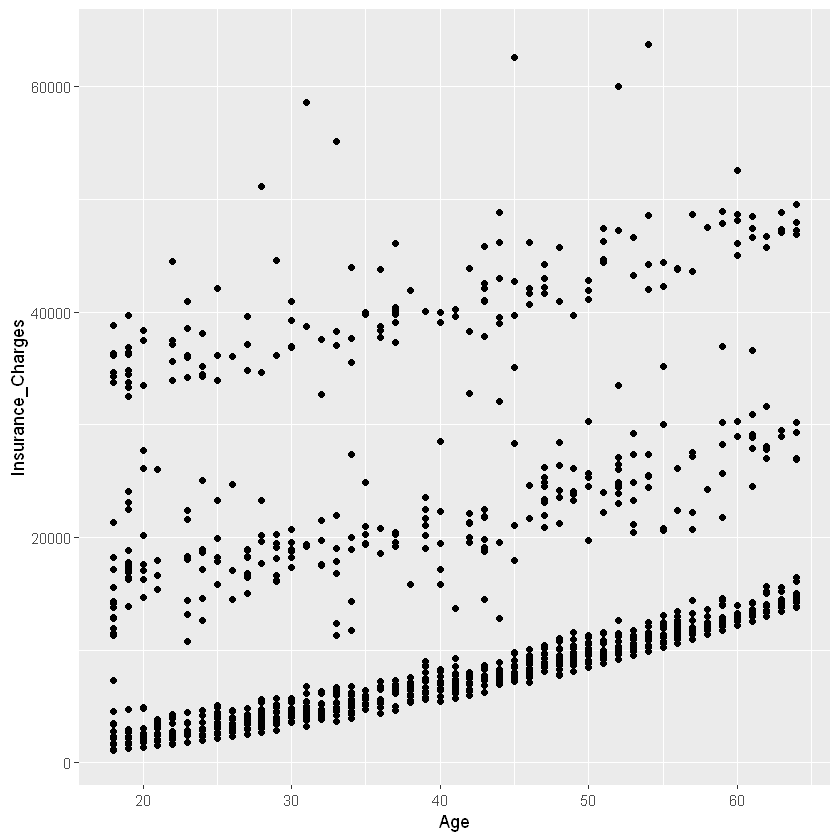

In [21]:
ggplot(data = ID, aes(x = Age, y = Insurance_Charges)) + 
    geom_point()

For age, there is strong visual evidence that insurance charges tend to increase as customers get older. For all three clusters, a positive 
trend can be observed. So generally, the older a customer is, the more they are charged. The three clusters are still present here so it's important to remember that there are other contributory variables.

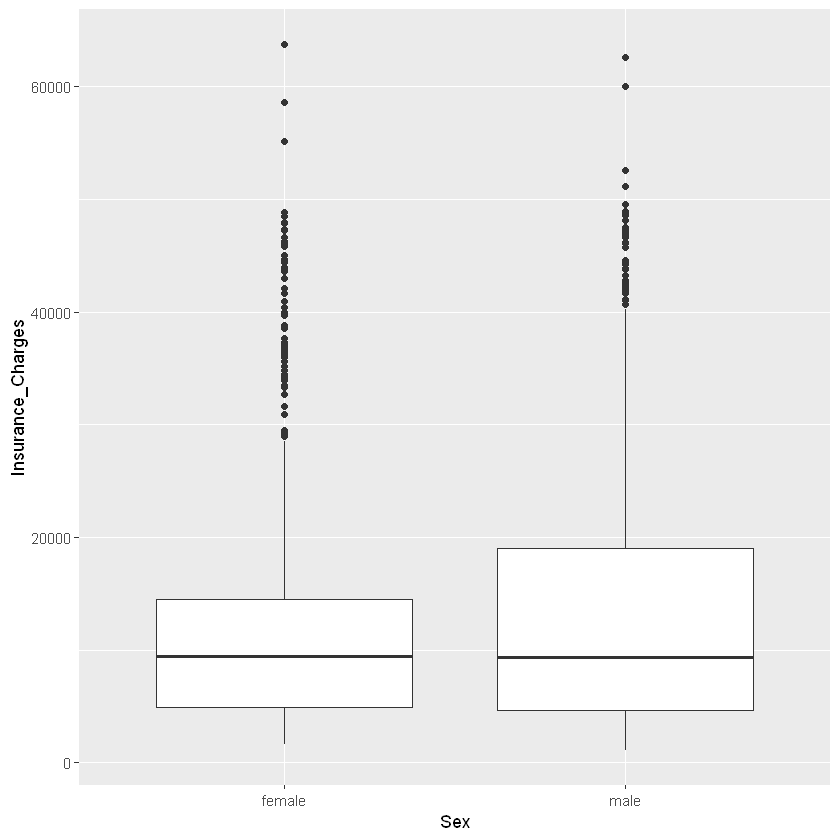

In [22]:
ggplot(data = ID, aes( x = Sex, y = Insurance_Charges)) +
    geom_boxplot()

There doesn't seem to be much difference between male and female customers in terms of their insurance charges. Outliers for females start at around 30,000 and for males start at around 40,000 so there may be a slight influence on insurance charges due to sex, but the boxplots are very similar. I think whilst I shouldn't dismiss sex as a contributory variable, there is stronger evidence for other variables having a much stronger apparent relationship with insurance charges.

In [23]:
table(ID$Number_of_Children)


  0   1   2   3   4   5 
574 324 240 157  25  18 

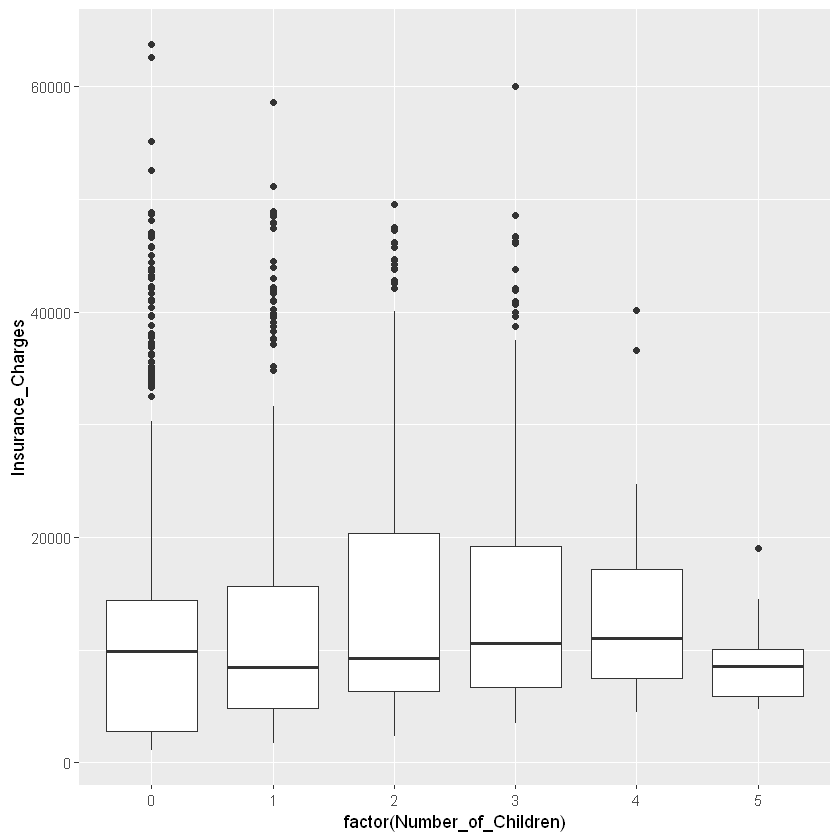

In [24]:
ggplot(data = ID, aes(x = factor(Number_of_Children), y = Insurance_Charges)) +
    geom_boxplot()

Given that there are fewer data entries with customers who have 4 or 5 children, it may be useful to treat these groups with caution, as they may provide a biased conclusion for how the number of children affects insurance charges. The boxplots seem to provide at least some evidence that having more children leads to higher insurance charges, but it isn't strong evidence. I do think that this should be tested when I make my models because it seems sensible to me to think that having more children would increase the potential for medical accidents to happen, as they are generally less responsible than adults. Again, the presence of many outliers indicate that the number of children alone isn't enough to explain insurance charges.  

In [25]:
ID %>%
    group_by(Number_of_Children) %>%
    summarise(
        count = n(),
        Mean_Charges = mean(Insurance_Charges),
        Median_Charges = median(Insurance_Charges)
        )

Number_of_Children,count,Mean_Charges,Median_Charges
<fct>,<int>,<dbl>,<dbl>
0,574,12365.976,9856.952
1,324,12731.172,8483.870
2,240,15073.564,9264.979
3,157,15355.318,10600.548
4,25,13850.656,11033.662
5,18,8786.035,8589.565


The numbers give a slightly clearer indication of higher insurance charges for customers who have 2 or 3 children so this variable should be included in my model making process.

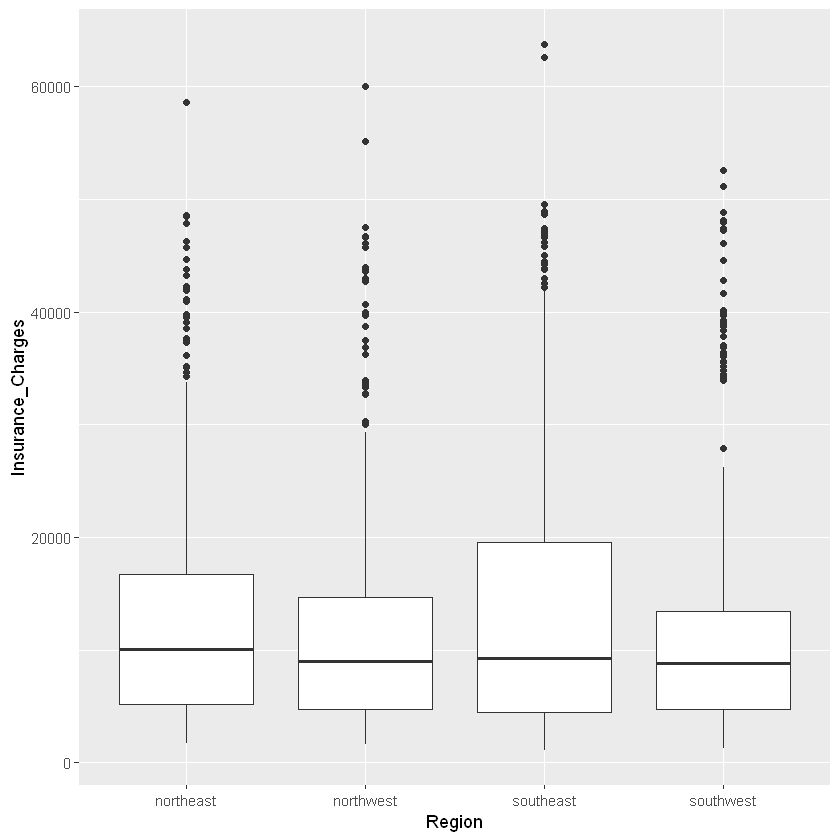

In [26]:
ggplot(data = ID, aes(x = Region, y = Insurance_Charges)) +
    geom_boxplot()

The medians for all groups are in a very similar location and there is a lot of overlap between the IQR's of the boxplots, suggesting that region isn't as strong as a predictor as smoking, age and BMI seem to be. It looks like the southwest region may produce slightly lower insurance charges and possibly the northwest, but I would model it before jumping to any conclusions. 

**Linear Model**

In [27]:
ID_LM_Model_1 <- lm(
  Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + Sex + Region,
  data = ID
)

summary(ID_LM_Model_1)


Call:
lm(formula = Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + 
    Sex + Region, data = ID)

Residuals:
     Min       1Q   Median       3Q      Max 
-11689.4  -2902.6   -943.7   1492.2  30042.7 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         -11927.17     993.66 -12.003  < 2e-16 ***
Smokeryes            23836.41     414.14  57.557  < 2e-16 ***
Age                    257.19      11.91  21.587  < 2e-16 ***
BMI                    336.91      28.61  11.775  < 2e-16 ***
Number_of_Children1    390.98     421.35   0.928 0.353619    
Number_of_Children2   1635.78     466.67   3.505 0.000471 ***
Number_of_Children3    964.34     548.10   1.759 0.078735 .  
Number_of_Children4   2947.37    1239.16   2.379 0.017524 *  
Number_of_Children5   1116.04    1456.02   0.767 0.443514    
Sexmale               -128.16     332.83  -0.385 0.700254    
Regionnorthwest       -380.04     476.56  -0.797 0.425318    
Regionsoutheast      -103

In [28]:
ID_LM_Model_2 <- lm(
  Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children,
  data = ID
)

summary(ID_LM_Model_2)


Call:
lm(formula = Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children, 
    data = ID)

Residuals:
     Min       1Q   Median       3Q      Max 
-12097.1  -2922.6   -950.7   1551.0  29566.8 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         -12093.32     947.78 -12.760  < 2e-16 ***
Smokeryes            23796.71     412.05  57.752  < 2e-16 ***
Age                    258.08      11.91  21.665  < 2e-16 ***
BMI                    319.80      27.38  11.682  < 2e-16 ***
Number_of_Children1    368.77     421.57   0.875 0.381868    
Number_of_Children2   1626.51     466.56   3.486 0.000506 ***
Number_of_Children3    996.95     547.80   1.820 0.068997 .  
Number_of_Children4   2984.36    1239.60   2.408 0.016197 *  
Number_of_Children5    899.13    1453.36   0.619 0.536250    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6064 on 1329 degrees of freedom
Multiple R-squared:  0.7508,	Adjusted R

The EDA and residuals hinted at there being problems with ordinary linear regression. And with the presence of many extreme values, a log transformation of the response variable will help compress the extreme values to create more linearity and reduce skew.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


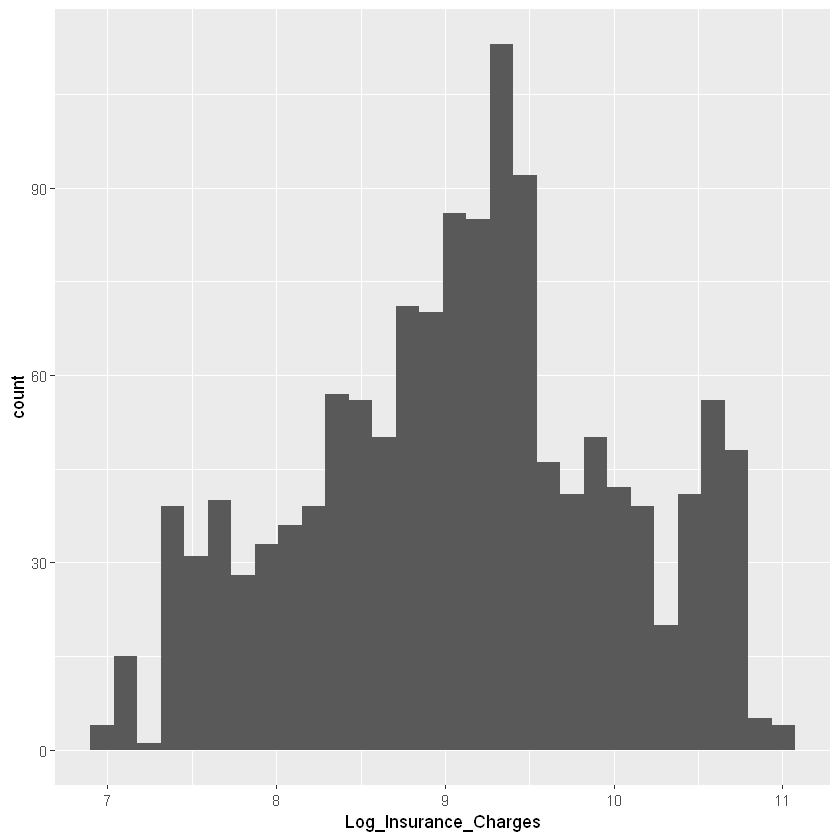

In [29]:
ID <- ID %>%
    mutate(Log_Insurance_Charges = log(Insurance_Charges))

ggplot(data = ID, aes(x = Log_Insurance_Charges)) +
    geom_histogram()



In [30]:
ID_Log_Model <- lm(Log_Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + Sex + Region,
  data = ID
)

summary(ID_Log_Model)


Call:
lm(formula = Log_Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + 
    Sex + Region, data = ID)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.04718 -0.20735 -0.05239  0.07369  2.14325 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.0159801  0.0726107  96.625  < 2e-16 ***
Smokeryes            1.5554864  0.0302628  51.399  < 2e-16 ***
Age                  0.0346256  0.0008706  39.770  < 2e-16 ***
BMI                  0.0132189  0.0020908   6.322 3.51e-10 ***
Number_of_Children1  0.1467848  0.0307898   4.767 2.07e-06 ***
Number_of_Children2  0.2813226  0.0341015   8.250 3.79e-16 ***
Number_of_Children3  0.2455353  0.0400517   6.130 1.15e-09 ***
Number_of_Children4  0.5173268  0.0905508   5.713 1.37e-08 ***
Number_of_Children5  0.4306893  0.1063971   4.048 5.47e-05 ***
Sexmale             -0.0757245  0.0243216  -3.113 0.001889 ** 
Regionnorthwest     -0.0657161  0.0348241  -1.887 0.059367 .  
Regionsou

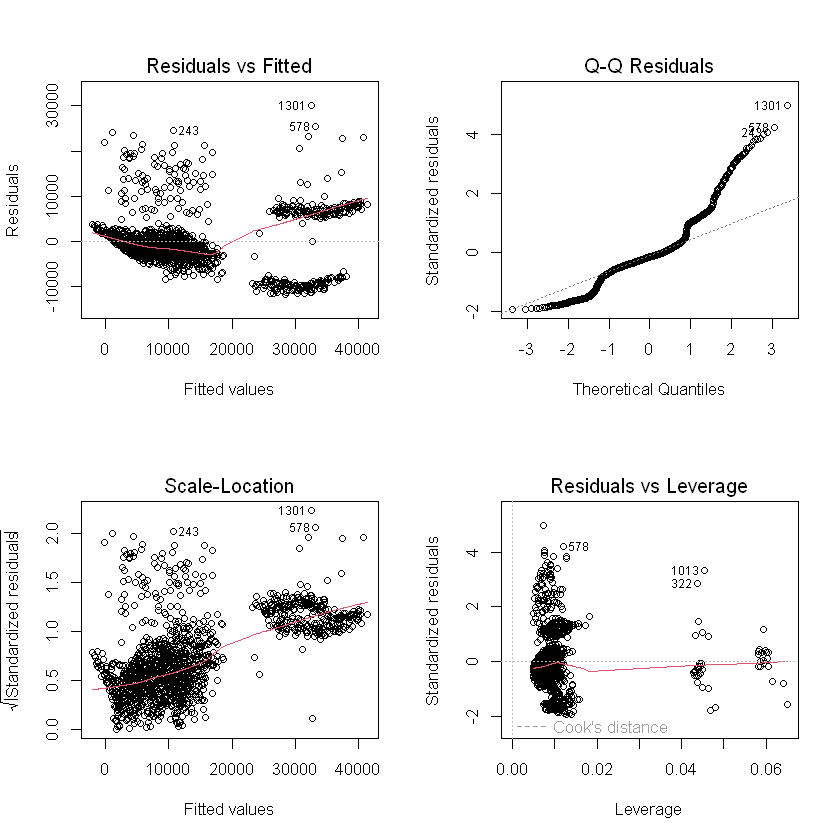

In [31]:
par(mfrow = c(2,2))
plot(ID_LM_Model_1)

par(mfrow = c(1,1))

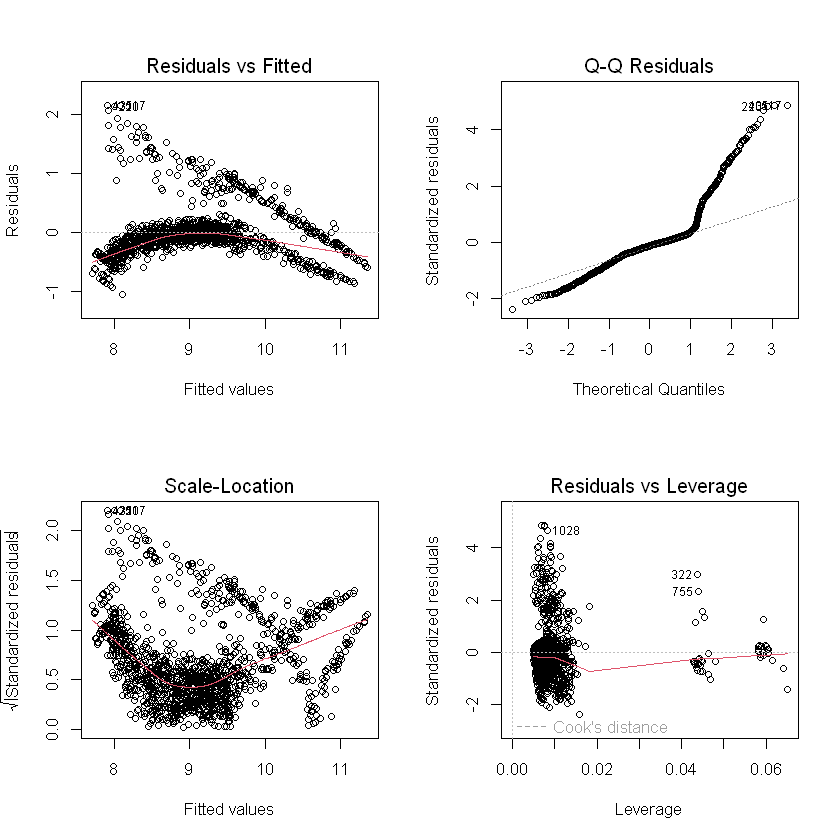

In [32]:
par(mfrow = c(2,2))
plot(ID_Log_Model)

par(mfrow = c(1,1))

**Comments and analysis:** \
Diagnostic plots for the original linear regression model indicated violations of several assumptions, including heteroscedasticity and non-normal residuals. A log transformation of insurance charges improved residual behaviour and reduced heteroscedasticity, although some structured patterns remained. This suggests that the underlying distribution of insurance charges may be better represented using alternative modelling approaches such as a Gamma GLM.

EDA gave strong evidence that BMI and smoking status had an impact causing more expensive insurance charges. Let's create the linear model with the log insurance charges being explained by smoking and BMI together, as well as the other important variables I believe are impacting cost.

In [33]:
ID_Interaction_Model <- lm(
  Log_Insurance_Charges ~
    Smoker * BMI +
    Age +
    Number_of_Children +
    Sex +
    Region,
  data = ID
)

summary(ID_Interaction_Model)


Call:
lm(formula = Log_Insurance_Charges ~ Smoker * BMI + Age + Number_of_Children + 
    Sex + Region, data = ID)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.83912 -0.19817 -0.04587  0.05353  2.20176 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.3224184  0.0768587  95.271  < 2e-16 ***
Smokeryes            0.1637927  0.1455223   1.126 0.260560    
BMI                  0.0033026  0.0022612   1.461 0.144370    
Age                  0.0348481  0.0008415  41.411  < 2e-16 ***
Number_of_Children1  0.1446764  0.0297501   4.863 1.29e-06 ***
Number_of_Children2  0.2779693  0.0329509   8.436  < 2e-16 ***
Number_of_Children3  0.2469577  0.0386985   6.382 2.42e-10 ***
Number_of_Children4  0.5326003  0.0875047   6.087 1.51e-09 ***
Number_of_Children5  0.4536262  0.1028283   4.411 1.11e-05 ***
Sexmale             -0.0874146  0.0235301  -3.715 0.000212 ***
Regionnorthwest     -0.0725935  0.0336547  -2.157 0.031184 *  
Regionsou

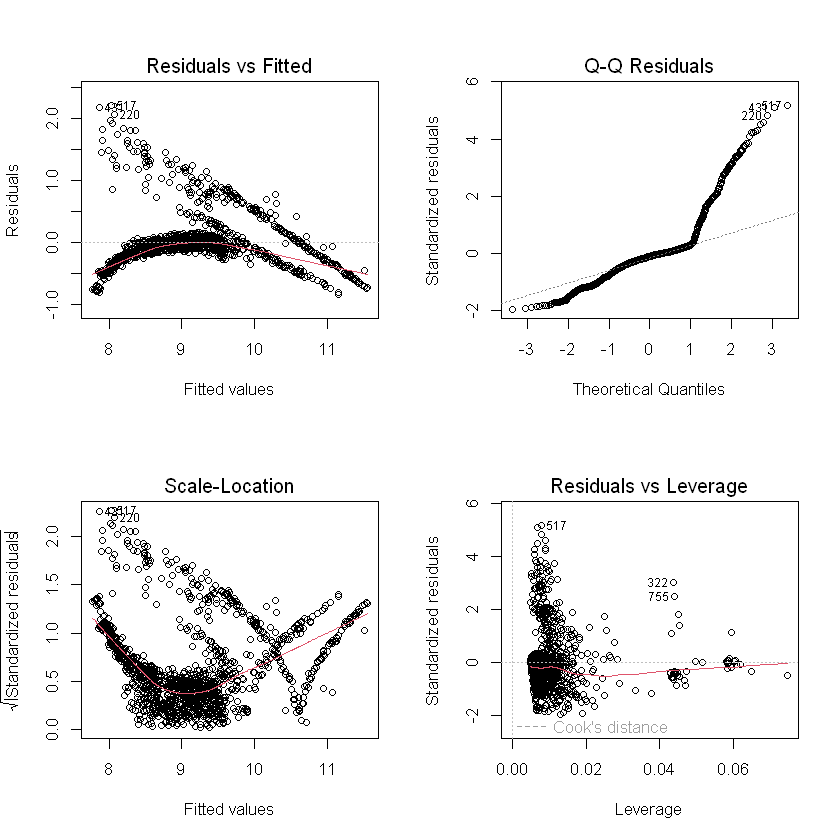

In [34]:
par(mfrow = c(2,2))
plot(ID_Interaction_Model)

par(mfrow = c(1,1))

The diagnostic plots are important in choosing a final model structure for the data I have. The residuals versus fitted values plot continues to display some structured patterns rather than complete randomness, suggesting that the model does not fully capture all sources of variation within the dataset. The Q-Q plot indicates departures from normality in the tails of the residual distribution, while the Scale-Location plot suggests some remaining heteroscedasticity.\
Although the interaction model provides useful insights into the relationship between smoking and BMI, these diagnostic plots suggest that ordinary linear regression assumptions are not fully satisfied. This provides additional justification for considering a Gamma Generalised Linear Model, which is more appropriate for positive, right-skewed insurance cost data.

Let's move onto Gamma Generalised Linear Models and see which models produce the optimal outcomes for modelling insurance charges.

In [35]:
ID_GLM_Model <- glm(Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + Sex + Region, data = ID, family = Gamma(link = "log"))
summary(ID_GLM_Model)


Call:
glm(formula = Insurance_Charges ~ Smoker + Age + BMI + Number_of_Children + 
    Sex + Region, family = Gamma(link = "log"), data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.367128   0.111015  66.361  < 2e-16 ***
Smokeryes            1.504652   0.046269  32.520  < 2e-16 ***
Age                  0.028886   0.001331  21.700  < 2e-16 ***
BMI                  0.013767   0.003197   4.307 1.78e-05 ***
Number_of_Children1  0.109604   0.047075   2.328 0.020047 *  
Number_of_Children2  0.271857   0.052138   5.214 2.14e-07 ***
Number_of_Children3  0.168542   0.061236   2.752 0.005998 ** 
Number_of_Children4  0.476530   0.138444   3.442 0.000595 ***
Number_of_Children5  0.277652   0.162672   1.707 0.088089 .  
Sexmale             -0.058168   0.037186  -1.564 0.117997    
Regionnorthwest     -0.056790   0.053243  -1.067 0.286339    
Regionsoutheast     -0.136151   0.053531  -2.543 0.011091 *  
Regionsouthwest     -0.140761   0.05

In [36]:
ID_GLM_Interaction <- glm(
  
  Insurance_Charges ~
    Smoker * BMI +
    Age +
    Number_of_Children +
    Sex +
    Region,
  
  family = Gamma(link = "log"),
  
  data = ID
)

ID_GLM_Interaction_2 <- glm(
  
  Insurance_Charges ~
    Smoker * BMI +
    Age +
    Number_of_Children +
    Region,
  
  family = Gamma(link = "log"),
  
  data = ID
)

summary(ID_GLM_Interaction)
summary(ID_GLM_Interaction_2)


Call:
glm(formula = Insurance_Charges ~ Smoker * BMI + Age + Number_of_Children + 
    Sex + Region, family = Gamma(link = "log"), data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.673067   0.119850  64.022  < 2e-16 ***
Smokeryes            0.048477   0.226921   0.214 0.830869    
BMI                  0.003638   0.003526   1.032 0.302314    
Age                  0.029268   0.001312  22.304  < 2e-16 ***
Number_of_Children1  0.107424   0.046391   2.316 0.020731 *  
Number_of_Children2  0.266597   0.051382   5.189 2.45e-07 ***
Number_of_Children3  0.170738   0.060345   2.829 0.004734 ** 
Number_of_Children4  0.494808   0.136451   3.626 0.000298 ***
Number_of_Children5  0.293932   0.160346   1.833 0.067010 .  
Sexmale             -0.069094   0.036692  -1.883 0.059906 .  
Regionnorthwest     -0.064320   0.052480  -1.226 0.220563    
Regionsoutheast     -0.147450   0.052759  -2.795 0.005269 ** 
Regionsouthwest     -0.149108   0.05


Call:
glm(formula = Insurance_Charges ~ Smoker * BMI + Age + Number_of_Children + 
    Region, family = Gamma(link = "log"), data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.646999   0.118463  64.552  < 2e-16 ***
Smokeryes            0.064540   0.226395   0.285 0.775629    
BMI                  0.003448   0.003519   0.980 0.327370    
Age                  0.029248   0.001310  22.333  < 2e-16 ***
Number_of_Children1  0.107023   0.046307   2.311 0.020976 *  
Number_of_Children2  0.265622   0.051293   5.178 2.58e-07 ***
Number_of_Children3  0.171487   0.060239   2.847 0.004485 ** 
Number_of_Children4  0.492650   0.136191   3.617 0.000309 ***
Number_of_Children5  0.286966   0.160043   1.793 0.073191 .  
Regionnorthwest     -0.064190   0.052389  -1.225 0.220693    
Regionsoutheast     -0.146790   0.052668  -2.787 0.005394 ** 
Regionsouthwest     -0.148859   0.052570  -2.832 0.004701 ** 
Smokeryes:BMI        0.046060   0.007228  

In [37]:
ID_GLM_2 <- glm(
  
  Insurance_Charges ~
    Smoker +
    BMI +
    Age +
    Number_of_Children +
    Region,
  
  family = Gamma(link = "log"),
  
  data = ID
)

ID_GLM_3 <- glm(
  
  Insurance_Charges ~
    Smoker +
    BMI +
    Age +
    Sex +
    Number_of_Children +
    Region,
  
  family = Gamma(link = "log"),
  
  data = ID
)

ID_GLM_4 <- glm(
  
  Insurance_Charges ~
    Smoker * BMI +
    Age +
    Sex +
    Number_of_Children +
    Region,
  
  family = Gamma(link = "log"),
  
  data = ID
)

summary(ID_GLM_2)
summary(ID_GLM_3)
summary(ID_GLM_4)


Call:
glm(formula = Insurance_Charges ~ Smoker + BMI + Age + Number_of_Children + 
    Region, family = Gamma(link = "log"), data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.348040   0.109899  66.862  < 2e-16 ***
Smokeryes            1.497504   0.046067  32.507  < 2e-16 ***
BMI                  0.013503   0.003188   4.235 2.44e-05 ***
Age                  0.028882   0.001329  21.736  < 2e-16 ***
Number_of_Children1  0.109163   0.047002   2.323 0.020355 *  
Number_of_Children2  0.270667   0.052062   5.199 2.32e-07 ***
Number_of_Children3  0.169100   0.061145   2.766 0.005761 ** 
Number_of_Children4  0.475126   0.138219   3.437 0.000605 ***
Number_of_Children5  0.270677   0.162410   1.667 0.095826 .  
Regionnorthwest     -0.056917   0.053165  -1.071 0.284554    
Regionsoutheast     -0.135528   0.053453  -2.535 0.011344 *  
Regionsouthwest     -0.140555   0.053343  -2.635 0.008513 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.0


Call:
glm(formula = Insurance_Charges ~ Smoker + BMI + Age + Sex + 
    Number_of_Children + Region, family = Gamma(link = "log"), 
    data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.367128   0.111015  66.361  < 2e-16 ***
Smokeryes            1.504652   0.046269  32.520  < 2e-16 ***
BMI                  0.013767   0.003197   4.307 1.78e-05 ***
Age                  0.028886   0.001331  21.700  < 2e-16 ***
Sexmale             -0.058168   0.037186  -1.564 0.117997    
Number_of_Children1  0.109604   0.047075   2.328 0.020047 *  
Number_of_Children2  0.271857   0.052138   5.214 2.14e-07 ***
Number_of_Children3  0.168542   0.061236   2.752 0.005998 ** 
Number_of_Children4  0.476530   0.138444   3.442 0.000595 ***
Number_of_Children5  0.277652   0.162672   1.707 0.088089 .  
Regionnorthwest     -0.056790   0.053243  -1.067 0.286339    
Regionsoutheast     -0.136151   0.053531  -2.543 0.011091 *  
Regionsouthwest     -0.140761  


Call:
glm(formula = Insurance_Charges ~ Smoker * BMI + Age + Sex + 
    Number_of_Children + Region, family = Gamma(link = "log"), 
    data = ID)

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)          7.673067   0.119850  64.022  < 2e-16 ***
Smokeryes            0.048477   0.226921   0.214 0.830869    
BMI                  0.003638   0.003526   1.032 0.302314    
Age                  0.029268   0.001312  22.304  < 2e-16 ***
Sexmale             -0.069094   0.036692  -1.883 0.059906 .  
Number_of_Children1  0.107424   0.046391   2.316 0.020731 *  
Number_of_Children2  0.266597   0.051382   5.189 2.45e-07 ***
Number_of_Children3  0.170738   0.060345   2.829 0.004734 ** 
Number_of_Children4  0.494808   0.136451   3.626 0.000298 ***
Number_of_Children5  0.293932   0.160346   1.833 0.067010 .  
Regionnorthwest     -0.064320   0.052480  -1.226 0.220563    
Regionsoutheast     -0.147450   0.052759  -2.795 0.005269 ** 
Regionsouthwest     -0.149108  

In [38]:
#chosen final model
ID_Final_Model <- ID_GLM_4

I investigated multiple modelling approaches, including linear regression, log-linear regression, and Gamma GLMs. The final selected model was a Gamma GLM with a log link including an interaction between Smoking Status and BMI. This model achieved the lowest AIC and residual deviance among the candidate models, suggesting that it provided the best balance between model fit and complexity. The interaction term indicated that the effect of BMI on insurance charges differs according to smoking status, with higher BMI associated with substantially greater insurance charges among smokers.

In [39]:
# Comparison of Gamma GLM models

GLM_Comparison <- data.frame(
  
  Model = c(
    "GLM 1: Main Effects",
    "GLM 2: Main Effects (No Sex)",
    "GLM 3: Smoker × BMI Interaction (No Sex)",
    "GLM 4: Final Model"
  ),
  
  AIC = round(c(
    AIC(ID_GLM_Model),
    AIC(ID_GLM_2),
    AIC(ID_GLM_Interaction_2),
    AIC(ID_Final_Model)
  ), 2),
  
  Residual_Deviance = round(c(
    deviance(ID_GLM_Model),
    deviance(ID_GLM_2),
    deviance(ID_GLM_Interaction_2),
    deviance(ID_Final_Model)
  ), 2)

)

GLM_Comparison

Model,AIC,Residual_Deviance
<chr>,<dbl>,<dbl>
GLM 1: Main Effects,26369.01,333.34
GLM 2: Main Effects (No Sex),26371.67,334.45
GLM 3: Smoker × BMI Interaction (No Sex),26302.22,317.72
GLM 4: Final Model,26297.32,316.15


In [40]:
# Sort by AIC

GLM_Comparison[order(GLM_Comparison$AIC), ]

,Model,AIC,Residual_Deviance
,<chr>,<dbl>,<dbl>
4,GLM 4: Final Model,26297.32,316.15
3,GLM 3: Smoker × BMI Interaction (No Sex),26302.22,317.72
1,GLM 1: Main Effects,26369.01,333.34
2,GLM 2: Main Effects (No Sex),26371.67,334.45


I investigated many Gamma Generalised Linear Models to determine the most appropriate model for the available data. The models were compared using both AIC and residual deviance, with lower values indicating improved model fit. The final model, which included an interaction between Smoking Status and BMI, achieved the lowest AIC and residual deviance of the candidate models and was therefore selected as the most appropriate for assisting insurance policy pricing.

**Conclusion and limitations**

For my project I investigated factors associated with medical insurance charges using exploratory data analysis and statistical modelling. My analysis discovered that smoking status was the strongest predictor of insurance charges, while age and BMI also had important effects. The interaction between smoking status and BMI was particularly valuable and interesting, suggesting that BMI has a stronger relationship with insurance charges when combined with smoking. \
Of the models I tested, the Gamma GLM with a log link and a Smoker × BMI interaction provided the best fit for the available data. This was appropriate because insurance charges are positive, right-skewed and better suited to multiplicative interpretation than a standard linear model. \
From a business perspective, the model could help insurance policy pricing by identifying key risk factors and estimating expected charges more accurately. However, the dataset is limited. Real-world insurance pricing would likely benefit from additional variables such as previous claims, occupation, medical history, lifestyle factors, policy type and pre-existing health conditions. Future analysis could improve the model by including these variables in the model making process and testing the model's predictive performance on unseen data using machine learning techniques.